In [ ]:
rm(list = ls())
gc()
setwd('/mnt/data00/minghui/project_NMF/07_Test_NMF_consensus_matrix/')
library(rliger)
library(dplyr)
library(cowplot)

library(Seurat)
library(ggplot2)
library(parallel)
library(foreach)
library(doParallel)
library(presto)
source('/mnt/data00/minghui/Fuctions/Markers_kno.R')

source('/mnt/data00/minghui/Fuctions/seurat_functions.R')

AllTissue_merge <-readRDS('../02_NMFAllTissue/03_AllTissue_merge.rds')

In [2]:
AllTissue_merge <-  FindVariableFeatures(AllTissue_merge, nfeatures = 3000,assay = 'RNA', selection.method = "vst")

AllTissue_merge <- ScaleData(AllTissue_merge,do.center = F)


Scaling data matrix



In [3]:
AllTissue_merge@assays$RNA$scale.data[1:4,1:5]

dim(AllTissue_merge@assays$RNA$scale.data)

,SRR8513799-CTCACACGTCACCCAG-1,SRR8513799-TACAGTGGTCATCCCT-1,SRR8513799-GCACATACACTGTCGG-1,SRR8513799-CTGAAACTCTGGCGAC-1,SRR8513799-AGTAGTCAGTGAAGAG-1
SAMD11,0.000000,0.000000,0.000000,0.00000,0.0000000
HES4,5.350925,5.730974,5.898348,1.61166,0.0000000
ISG15,0.000000,0.000000,0.000000,0.00000,0.8921329
TNFRSF18,0.000000,0.000000,0.000000,0.00000,0.0000000


[1]  3000 79522

In [4]:
head(rownames(AllTissue_merge@assays$RNA$scale.data))

[1] "SAMD11"   "HES4"     "ISG15"    "TNFRSF18" "TNFRSF4"  "C1QTNF12"

In [5]:
split_list <- readRDS('/mnt/data00/minghui/project_NMF/02_NMFAllTissue/01_split_list.rds')

length(split_list)

[1] 74

In [ ]:
suppressWarnings({ 
    
plot_list = list() 

# Iterate over each split object

for (i in names(split_list)) { 
  # Discard data with less than 150 columns
  if (ncol(split_list[[i]]) < 150) {
    next
  }
  
  split_list[[i]] = ScaleData(split_list[[i]], features =rownames(AllTissue_merge@assays$RNA$scale.data),do.center = F) %>%
    RunPCA() %>%
    FindNeighbors() %>%
    FindClusters(resolution = 1)

  p = DotPlot(split_list[[i]], group.by = 'seurat_clusters', features = unique(Markers_kno), cluster.idents = T, col.min = 0) + coord_flip()
  
  plot_list[[i]] = p 
}  

pdf("./02_merge.list_plots.pdf") 
for (i in  1:length(plot_list)) { 
  print(plot_list[[i]]) 
} 
dev.off()

})


In [ ]:
suppressWarnings({ 

path <- "./01_NMF_res/"
set.seed(123) 

if (!dir.exists(path)) {
  dir.create(path)
}


range = 3:15
gmin = 3
ncores = 20

for( i in names(split_list) ) {
  obj = ScaleData(split_list[[i]], features =rownames(AllTissue_merge@assays$RNA$scale.data),do.center = F)
  
  data = GetAssayData(obj, slot = 'scale.data') %>% as.matrix()
#   data = data[VariableFeatures(obj),]
  data[data < 0] = 0
#   data = data[apply(data, 1, var) > 0, ]
  zero_var_rows <- which(apply(data, 1, var) == 0)


for (j in zero_var_rows) {
  col_index <- sample(ncol(data), 1)  
  data[j, col_index] <- 1e-10 
}

  if (ncol(data) > 150) {
    res.list = parallel::mclapply(range, function(r){
      nmf(data, rank = r, nrun = 1, seed = 'ica', method = 'nsNMF')
    }, mc.cores = ncores)
    names(res.list) = range
    saveRDS(res.list,file = paste0(path,i ,"_res.list.rds"))
    print(i)
  }
} 
    
    
})

In [7]:
path <- "./01_NMF_res/"


NMF_Sample_Patient <- c()

files <- list.files(path)

 NMF_Sample_Patient <- c()

 
for (file in files) {
  if (!grepl("_res.list.rds", file)) {
    next
  }

  NMF_Sample_Patient <- c(NMF_Sample_Patient, gsub("_res.list.rds", "", file))
}

NMF_Sample_Patient

length(NMF_Sample_Patient) # 31 normal samples in total (cells > 150)

[1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  
[40] "Patient14_SIGAE8_GIM"  "Patient14_SIGAF8_NG"   "Patient15_SIGAH11_NG" 
[43] "Patient16_SIGAA1_GIM"  "Patient16_SIGAB1_CIM"  "Patient16_SIGAC1_NG"  
[46] "Patient17_SIGAG7_CIM"  "Patient17_SIGAH1_GIM"  "Patient17_SIGAH7_NG"  
[49] "Patient18_SIGAA3_GM"   "Patient19_SIGAB3_BE"   "Patient20_SIGAC3_GM"  
[52] "Patient21_SIGAA1_GIM"  "Patient21_SIGAB1_CIM"  "Patient21_SIGAC1_NG"  
[55] "Patient22_SIGAE9_GIM"  "Patient22_SIGAF9_CIM"  "Patient22_SIGAG9_NG"  
[58] "SRR8513794"            "SRR8513795"            "SRR8513796"           
[61] "SRR8513797"            "SRR8513798"            "SRR8513799"

[1] 63

In [8]:
path <- "./01_NMF_res/"

res.list_L<- list()

for(i in  NMF_Sample_Patient){
    a <- readRDS(paste0(path,i ,"_res.list.rds"))
    res.list_L[[i]] <- a
}

In [ ]:
names(res.list_L) <- NMF_Sample_Patient
     
modules_L <- list()
res_optima_L <- list()
coefs_L <- list()
scores_L <- list()
gmin = 3

for (i in NMF_Sample_Patient) { 
    if (!is.null(res.list_L[[i]])) {
        modules.list = lapply(res.list_L[[i]], function(x) if (!is.null(x)) NMFToModules(x, gmin = gmin) else NULL)
        
        modules.list = Filter(Negate(is.null), modules.list)
        
        print(sapply(modules.list, length))
        
        comp = as.numeric(names(modules.list)) - sapply(modules.list, length)
        mi = min(comp)
        r = names(which(comp == mi))
        r = r[length(r)]
        res = res.list_L[[i]][[r]]
        modules = NMFToModules(res, gmin = gmin)
        
        scores = as.matrix(basis(res))
        colnames(scores) = names(modules)
        
        coefs = as.matrix(coefficients(res))
        rownames(coefs) = names(modules)
        
        h = Heatmap(coefs, clustering_distance_columns = 'euclidean')
        o = row_order(h)
        scores = scores[, o]
        coefs = coefs[o, ]
        modules = modules[o]
        
        modules_L[[i]] <- modules
        res_optima_L[[i]] <- res
        coefs_L[[i]] <- coefs
        scores_L[[i]] <- scores
    } else {
        
        modules_L[[i]] <- NULL
        res_optima_L[[i]] <- NULL
        coefs_L[[i]] <- NULL
        scores_L[[i]] <- NULL
    }
}

saveRDS(object = modules_L, file = "./01_NMF_res/03_modules_L.rds")
saveRDS(object = res_optima_L, file = "./01_NMF_res/03_res_optima_L.rds")
saveRDS(object = coefs_L, file = "./01_NMF_res/03_coefs_L.rds")
saveRDS(object = scores_L, file = "./01_NMF_res/03_scores_L.rds")


In [9]:
scores_L <-readRDS('./01_NMF_res/03_scores_L.rds')


scores_L[[i]] <- t(apply(scores_L[[i]], 1, function(row) {
  if(all(row == 0)) {
    min_val <- min(scores_L[[i]][scores_L[[i]] != 0])
      
    rep(min_val / sqrt(length(row) * min_val^2), length(row))
  } else {
    row / sqrt(sum(row^2))
  }
}))

In [10]:
# scores_L <-readRDS('./03_scores_L.rds')

identical(rownames(scores_L[[1]]),rownames(scores_L[[3]])) #HGV are same

# rename every modules by using sample name + module number
scores_L <- lapply(seq_along(scores_L), function(i) {
  colnames(scores_L[[i]]) <- paste0(names(scores_L)[i], '_module', seq(ncol(scores_L[[i]])))
  scores_L[[i]]
})

scores_L[[5]][1:4,1:5]

merge_matrix <- do.call(cbind ,scores_L)

dim(merge_matrix)

merge_matrix[1:4,1:5]

any(duplicated(merge_matrix)) #check if the rownames are duplicated

[1] TRUE

,GSM3954950_module1,GSM3954950_module2,GSM3954950_module3,GSM3954950_module4,GSM3954950_module5
SAMD11,0.000000e+00,4.076250e-207,8.331781e-316,0.000000e+00,4.940656e-324
HES4,0.000000e+00,1.923084e-04,0.000000e+00,4.940656e-324,0.000000e+00
ISG15,4.681319e-80,1.716809e-73,2.051132e-03,3.829884e-84,2.012125e-03
TNFRSF18,4.940656e-324,3.711515e-04,1.863530e-167,4.940656e-324,3.554481e-04


[1] 3000  851

,GSM3954946_module1,GSM3954946_module2,GSM3954946_module3,GSM3954946_module4,GSM3954946_module5
SAMD11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
HES4,6.155831e-04,1.088147e-04,0.000000e+00,1.976263e-323,4.940656e-324
ISG15,4.878356e-168,1.076567e-109,6.453813e-147,1.783074e-60,8.411417e-03
TNFRSF18,0.000000e+00,2.293489e-200,2.165988e-04,1.774654e-04,0.000000e+00


[1] FALSE

In [11]:
# filter_columns_by_neighbors <- function(data_matrix, min_neighbor_ratio = 0.3) {
#   col_dist <- dist(t(data_matrix), method = "euclidean")
#   dist_matrix <- as.matrix(col_dist)
  
#   k <- max(1, floor(ncol(data_matrix) * min_neighbor_ratio))
  
#   neighbor_indices <- apply(dist_matrix, 2, function(x) {
#     order(x)[2:(k+1)]  
#   })
  
#   neighbor_counts <- numeric(ncol(data_matrix))
  
#   for (i in 1:ncol(data_matrix)) {
#     neighbor_counts[i] <- sum(neighbor_indices == i, na.rm = TRUE)
#   }
  
#   # 30%
#   keep_cols <- neighbor_counts >= (ncol(data_matrix) * min_neighbor_ratio)
  
#   return(data_matrix[, keep_cols, drop = FALSE])
# }
#  filtered_data <- filter_columns_by_neighbors(merge_matrix, 0.3)

In [107]:
#   filter_columns_by_similarity_within_sample <- function(data_matrix, 
#                                                      min_neighbors = 3, 
#                                                      similarity_percentile = 0.5,
#                                                      dist_method = "euclidean",
#                                                      verbose = TRUE) {


#   sample_labels <- sapply(strsplit(colnames(data_matrix), "_mod", fixed = TRUE), `[`, 1)
#   unique_samples <- unique(sample_labels)
  
#   if (verbose) {
#     message(sprintf("processing %d ncol data，from %d n smaples: %s",
#                    ncol(data_matrix), 
#                    length(unique_samples),
#                    paste(unique_samples, collapse = ", ")))
#   }
  
#   # 初始化结果向量
#   keep_cols <- logical(ncol(data_matrix))
#   names(keep_cols) <- colnames(data_matrix)
  
#   # 对每个样本单独处理
#   for (sample in unique_samples) {
#     sample_cols <- which(sample_labels == sample)
    
#     if (length(sample_cols) < 2) {
#       if (verbose) message(sprintf("samples %s only  %d column，jump to next", sample, length(sample_cols)))
#       keep_cols[sample_cols] <- TRUE  # 保留单列
#       next
#     }
    
#     # 计算当前样本的距离矩阵
#     sample_data <- data_matrix[, sample_cols, drop = FALSE]
    
# #     if (dist_method == "correlation") {
# #       cor_matrix <- cor(sample_data)
# #       dist_matrix <- as.matrix(1 - cor_matrix)
# #     } else {
#       col_dist <- dist(t(sample_data), method = dist_method)
#       dist_matrix <- as.matrix(col_dist)
# #     }
    
#     diag(dist_matrix) <- Inf  # 忽略自距离
    
#     # 确定当前样本需要保留的最近邻数量
#     k <- max(1, floor(length(sample_cols) * similarity_percentile))
    
#     if (verbose) {
#       message(sprintf("sample %s: use %s distance，keep top %.1f%% sim nearest (k=%d)",
#                      sample, dist_method, similarity_percentile*100, k))
#     }
    
#     # 找出每个列的k个最近邻(仅限同一样本内)
#     neighbor_indices <- apply(dist_matrix, 2, function(x) {
#       order(x)[1:min(k, length(x)-1)]  # 排除自身
#     })
    
#     # 统计每个列被选为邻居的次数
#     neighbor_counts <- numeric(length(sample_cols))
    
#     for (i in 1:length(sample_cols)) {
#       neighbor_counts[i] <- sum(neighbor_indices == i, na.rm = TRUE)
#     }
    
#     # 判断哪些列应该保留
#     sample_keep <- neighbor_counts >= min_neighbors
    
#     if (verbose) {
#       message(sprintf("sample %s: keep %d/%d column (%.1f%%)",
#                      sample, sum(sample_keep), length(sample_keep),
#                      sum(sample_keep)/length(sample_keep)*100))
#     }
    
#     keep_cols[sample_cols] <- sample_keep
#   }
  
#   if (verbose) {
#     message(sprintf("keep %d/%d column (%.1f%%) in total",
#                    sum(keep_cols), length(keep_cols),
#                    sum(keep_cols)/length(keep_cols)*100))
#   }
  
#   return(data_matrix[, keep_cols, drop = FALSE])
# }


In [ ]:
# filtered_data <- filter_columns_by_similarity_within_sample(
#   merge_matrix,
#   min_neighbors =4,
#   similarity_percentile = 0.4,
#   dist_method = "euclidean",
#   verbose = TRUE
# )

# dim(filtered_data)


In [ ]:
# max_k = 50
#  wss <- sapply(1:50, function(k) {
#     kmeans(t(merge_matrix), centers = k, nstart = 25)$tot.withinss
#   })

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


In [11]:
# Parallel
max_k = 50

cl <- makeCluster(20)
registerDoParallel(cl)

wss <- foreach(k = 1:max_k, .combine = c) %dopar% {
  kmeans(t(merge_matrix), centers = k, nstart = 25)$tot.withinss
}

stopCluster(cl) 


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators



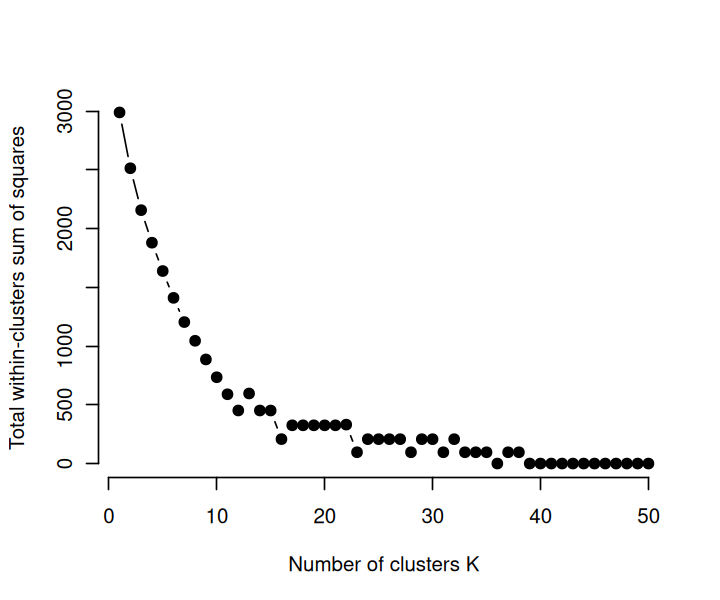

In [12]:
max_k = 50
options(repr.plot.width =6, repr.plot.height=5)

plot(1:max_k, wss, type = "b", pch = 19, frame = FALSE, 
       xlab = "Number of clusters K",
       ylab = "Total within-clusters sum of squares")

In [114]:
saveRDSSSSSDS(merge_matrix,'./01_NMF_res/merge_matrix.rds')

In [13]:
  k <- 38

In [14]:
cluster_components <- function(filtered_data, k = NULL) {
 set.seed(123)  
  kmeans_result <- kmeans(t(merge_matrix), centers = k, nstart = 25)
  
  return(list(
    clusters = kmeans_result$cluster,
    centers = kmeans_result$centers,
    totss = kmeans_result$totss,
    withinss = kmeans_result$withinss,
    tot.withinss = kmeans_result$tot.withinss,
    betweenss = kmeans_result$betweenss,
    size = kmeans_result$size,
    k = k
  ))
}

clustering_result <- cluster_components(merge_matrix, k = k)


In [15]:
clustering_result$clusters %>% table 

.
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 1  1 22 74 39 49 14  1  1 27 36 38 13  5  1 20  1 48  1  1 57 63  1 33  1  1 
27 28 29 30 31 32 33 34 35 36 37 38 
 1 23 86 29  1 25 30 19  1  1 32 54 

In [17]:
  clusters <- clustering_result$clusters
#   k <- 10
  
  consensus_components <- matrix(NA, nrow = nrow(merge_matrix), ncol = k)
  rownames(consensus_components) <- rownames(merge_matrix)
  colnames(consensus_components) <- paste0("Consensus_", 1:k)
  
  for (i in 1:k) {
    cluster_data <- merge_matrix[, clusters == i, drop = FALSE]
    
    if (ncol(cluster_data) > 0) {
      consensus_components[, i] <- apply(cluster_data, 1, median, na.rm = TRUE)
    } else {
      warning(paste("Cluster", i, "is empty. Consensus component will be NA."))
      consensus_components[, i] <- NA
    }
  }
  
res <- list(
    consensus_components = consensus_components,
    cluster_assignments = clusters,
    cluster_sizes = table(clusters),
    k = k
  )

In [96]:

#   heatmap(res$consensus_components,
#           Colv = NA, Rowv = NA,
#           col = colorRampPalette(c("blue", "white", "red"))(100),
#           scale = "row",  # 按行标准化
#           main = "Consensus Components (Median)",
#           xlab = "Consensus Components",
#           ylab = "Features",
#           labCol = paste("Cluster", 1:ncol(res$consensus_components)))




In [56]:
  row_sums <- rowSums(abs(consensus_components), na.rm = TRUE)
  row_sums[row_sums == 0] <- 1e-10

  norm_components <- consensus_components / row_sums


In [99]:
AllTissue_merge <- subset(AllTissue_merge,sample_name %in% NMF_Sample_Patient)
AllTissue_merge  <- ScaleData(object = AllTissue_merge,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- AllTissue_merge@assays$RNA@scale.data


Scaling data matrix



In [101]:
 n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)


In [21]:
#   for (i in 1:n_cells) {
#     # NNLS
#     fit <- nnls::nnls(norm_components, norm_expression[, i])
#     usage_matrix[i, ] <- fit$x
#   }
   

In [102]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [103]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, norm_components)
})

usage_matrix <- do.call(rbind, results)

In [104]:
saveRDS(usage_matrix, './01_NMF_res/usage_matrix.rds')

In [105]:
row_sums <- rowSums(usage_matrix)
  
  row_sums[row_sums == 0] <- 1e-10
  
  norm_usage <- usage_matrix / row_sums

In [106]:
AllTissue_merge[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(norm_usage),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [107]:
k

[1] 38

In [108]:
head(norm_usage)

,Consensus_1,Consensus_2,Consensus_3,Consensus_4,Consensus_5,Consensus_6,Consensus_7,Consensus_8,Consensus_9,Consensus_10,⋯,Consensus_29,Consensus_30,Consensus_31,Consensus_32,Consensus_33,Consensus_34,Consensus_35,Consensus_36,Consensus_37,Consensus_38
SRR8513799-CTCACACGTCACCCAG-1,0.000000e+00,0.0000000000,0,0,0,0,0.18341025,0.000000e+00,2.065312e-06,0.04153956,⋯,0,0.0000000,0.000000e+00,0.05809064,0.02869753,0.00000000,0.000000e+00,1.277037e-04,0.2168852,0
SRR8513799-TACAGTGGTCATCCCT-1,0.000000e+00,0.0000000000,0,0,0,0,0.38795158,0.000000e+00,7.295781e-05,0.03768345,⋯,0,0.0000000,6.843431e-05,0.09425000,0.00000000,0.01546457,1.566829e-05,5.175708e-04,0.3280402,0
SRR8513799-GCACATACACTGTCGG-1,0.000000e+00,0.0000000000,0,0,0,0,0.48229560,0.000000e+00,8.153992e-05,0.03095795,⋯,0,0.0000000,1.104349e-04,0.01777674,0.00000000,0.00000000,0.000000e+00,4.404129e-04,0.3604750,0
SRR8513799-CTGAAACTCTGGCGAC-1,1.519011e-05,0.0000000000,0,0,0,0,0.14203380,0.000000e+00,8.379804e-05,0.02283663,⋯,0,0.0000000,8.609932e-05,0.35869535,0.00000000,0.00000000,2.196433e-04,9.555552e-05,0.2995228,0
SRR8513799-AGTAGTCAGTGAAGAG-1,2.677219e-05,0.0001087931,0,0,0,0,0.02352649,0.000000e+00,7.013141e-05,0.40695939,⋯,0,0.0000000,8.548448e-05,0.00000000,0.00000000,0.00000000,0.000000e+00,2.376446e-05,0.3261238,0
SRR8513799-ATCCGAACAACGATGG-1,1.927952e-04,0.0000000000,0,0,0,0,0.11846738,8.281163e-05,3.271078e-04,0.46363754,⋯,0,0.2177028,1.782119e-04,0.01451505,0.00000000,0.00000000,2.033166e-05,0.000000e+00,0.0000000,0


In [ ]:
AllTissue_merge <- FindNeighbors(AllTissue_merge, dims = 1:k, reduction = 'Consensus')
AllTissue_merge <- RunUMAP(AllTissue_merge, reduction = 'Consensus', dims = 1:k)

AllTissue_merge <- FindClusters(AllTissue_merge,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

In [111]:
cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

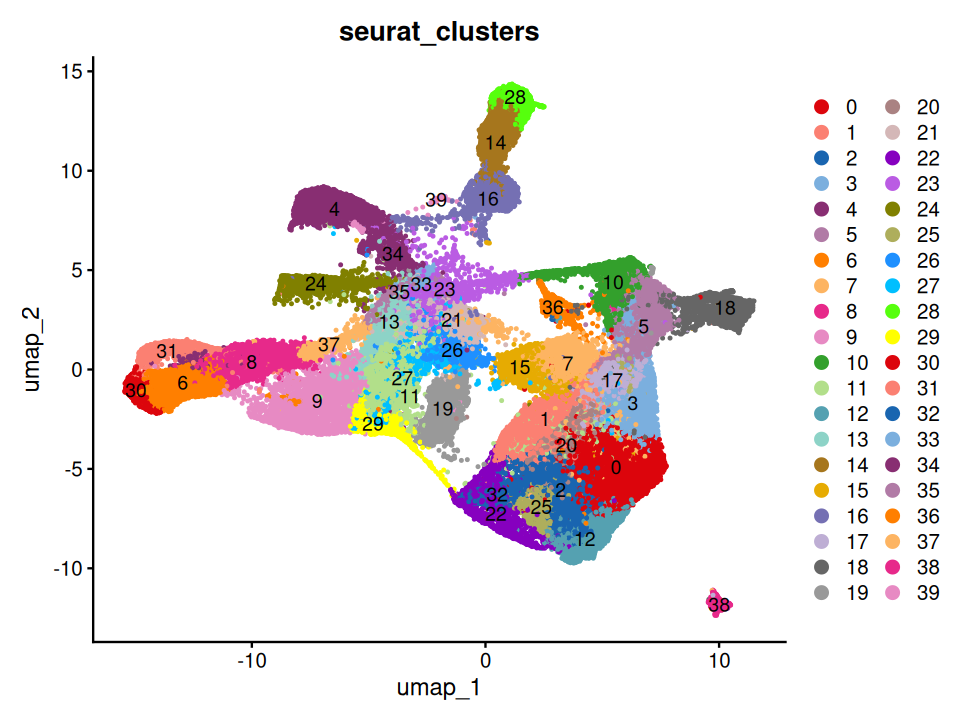

In [131]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c('seurat_clusters'),label = T,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))


In [132]:
pdf('./01_NMF_res/DimPlot_with_label.pdf',width = 8,height =6)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c('seurat_clusters'),label = T,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))
dev.off()

pdf 
  2

In [133]:
png('./01_NMF_res/DimPlot_with_label.png',units = 'in',res = 300,width = 8,height =6)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c('seurat_clusters'),label = T,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))
dev.off()

pdf 
  2

In [117]:
Consensus_markers <- FindAllMarkers(AllTissue_merge,group.by =  'seurat_clusters',verbose = T,logfc.threshold = 1,only.pos = T,min.pct = 0.25,min.diff.pct = 0.25)

Consensus_markers %>% dim

Consensus_markers %>% head(20)

# split(Consensus_markers$gene)

[1] 7123    7

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
GKN2,0,1.392047,0.933,0.397,0,0,GKN2
MUC5AC,0,1.377483,0.983,0.590,0,0,MUC5AC
CLDN18,0,1.488573,0.935,0.590,0,0,CLDN18
S100P,0,1.141851,0.973,0.651,0,0,S100P
KLF2,0,1.812946,0.697,0.391,0,0,KLF2
TACSTD2,0,1.736550,0.701,0.403,0,0,TACSTD2
TFF1,0,1.575813,0.999,0.733,0,0,TFF1
ANXA10,0,1.086071,0.760,0.499,0,0,ANXA10
CTSE,0,1.142610,0.836,0.577,0,0,CTSE


In [118]:
saveRDS(Consensus_markers,'./01_NMF_res/Consensus_markers.rds')

In [115]:
Consensus_markers <- Consensus_markers[Consensus_markers$p_val_adj < 0.05, ]
top_markers <- Consensus_markers %>% group_by(cluster) %>% top_n(n = 5, wt = avg_log2FC)


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


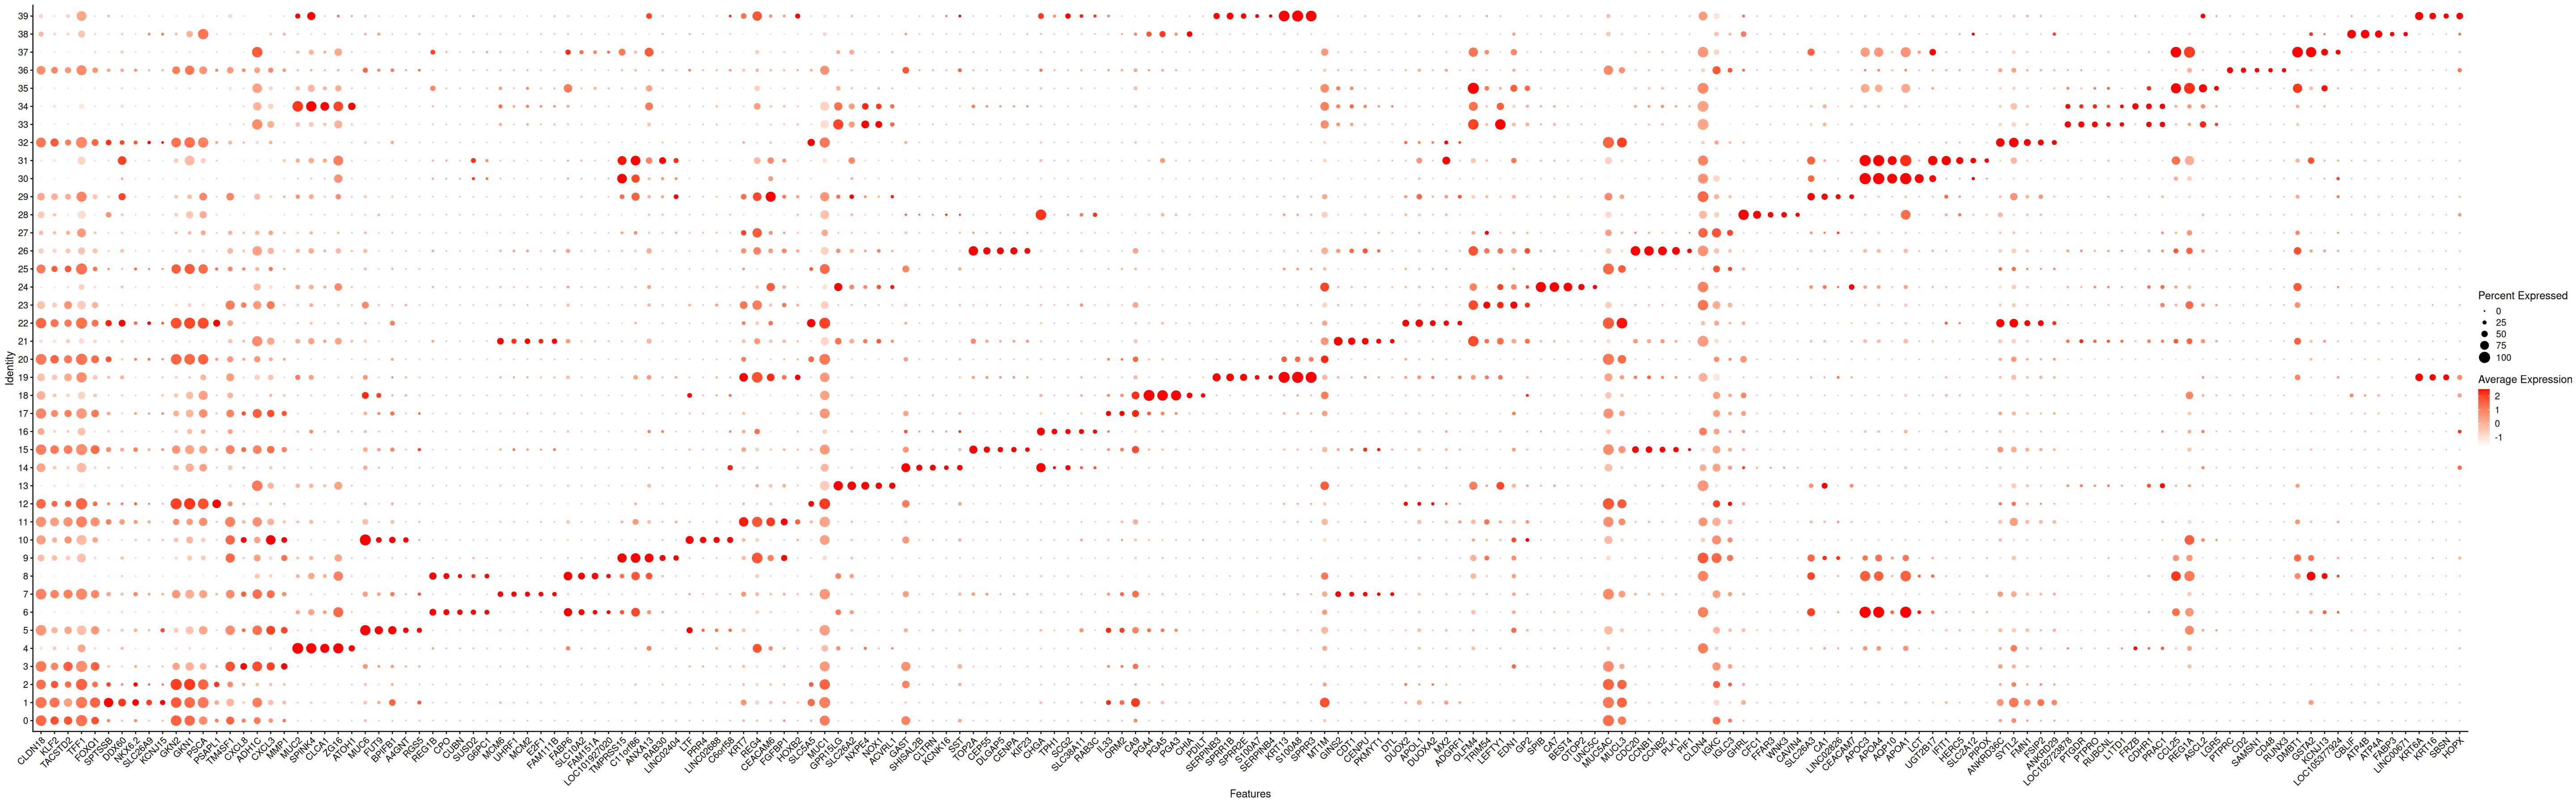

In [135]:
options(repr.plot.width =48, repr.plot.height=15)

DotPlot(AllTissue_merge, features = unique(top_markers$gene) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")

pdf('./01_NMF_res/DotPlot.pdf',width = 15,height = 48)
DotPlot(AllTissue_merge, features = unique(top_markers$gene) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")
dev.off()

png('./01_NMF_res/DotPlot.png',width = 15,height = 48,units = 'in',res = 400)
DotPlot(AllTissue_merge, features = unique(top_markers$gene) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")
dev.off()

In [137]:
source('/mnt/data00/minghui/Fuctions/Markers_kno.R')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


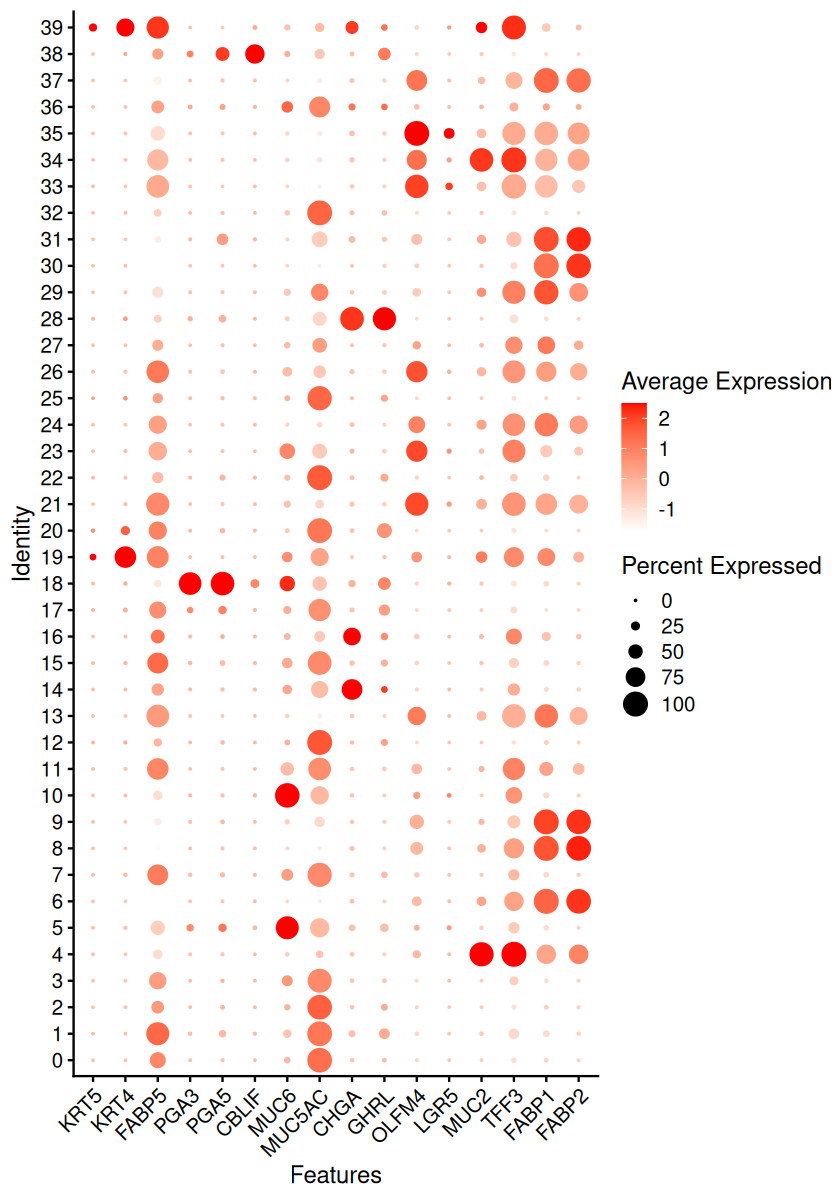

In [140]:
options(repr.plot.width =7, repr.plot.height=10)

DotPlot(AllTissue_merge, features = unique(Markers_kno) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")

pdf('./01_NMF_res/DotPlot2.pdf',width = 7,height = 10)
DotPlot(AllTissue_merge, features = unique(Markers_kno) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")
dev.off()

png('./01_NMF_res/DotPlot2.png',width = 7,height = 10,units = 'in',res = 400)
DotPlot(AllTissue_merge, features = unique(Markers_kno) )+ RotatedAxis()+ 
  scale_color_gradient(low = "white", high = "red")
dev.off()

In [157]:
Markers_kno

Basal_Cells      Superficial_Cells       Suprabasal_Cells 
                "KRT5"                 "KRT4"                "FABP5" 
          Chief_Cells1           Chief_Cells2         Parietal_Cells 
                "PGA3"                 "PGA5"                "CBLIF" 
     Mucous_Neck_Cells         Foveolar_Cells Enteroendocrine_Cells1 
                "MUC6"               "MUC5AC"                 "CHGA" 
Enteroendocrine_Cells2 Intestinal_Stem_Cells1 Intestinal_Stem_Cells2 
                "GHRL"                "OLFM4"                 "LGR5" 
         Goblet_Cells1          Goblet_Cells2           Enterocytes1 
                "MUC2"                 "TFF3"                "FABP1" 
          Enterocytes2 
               "FABP2"

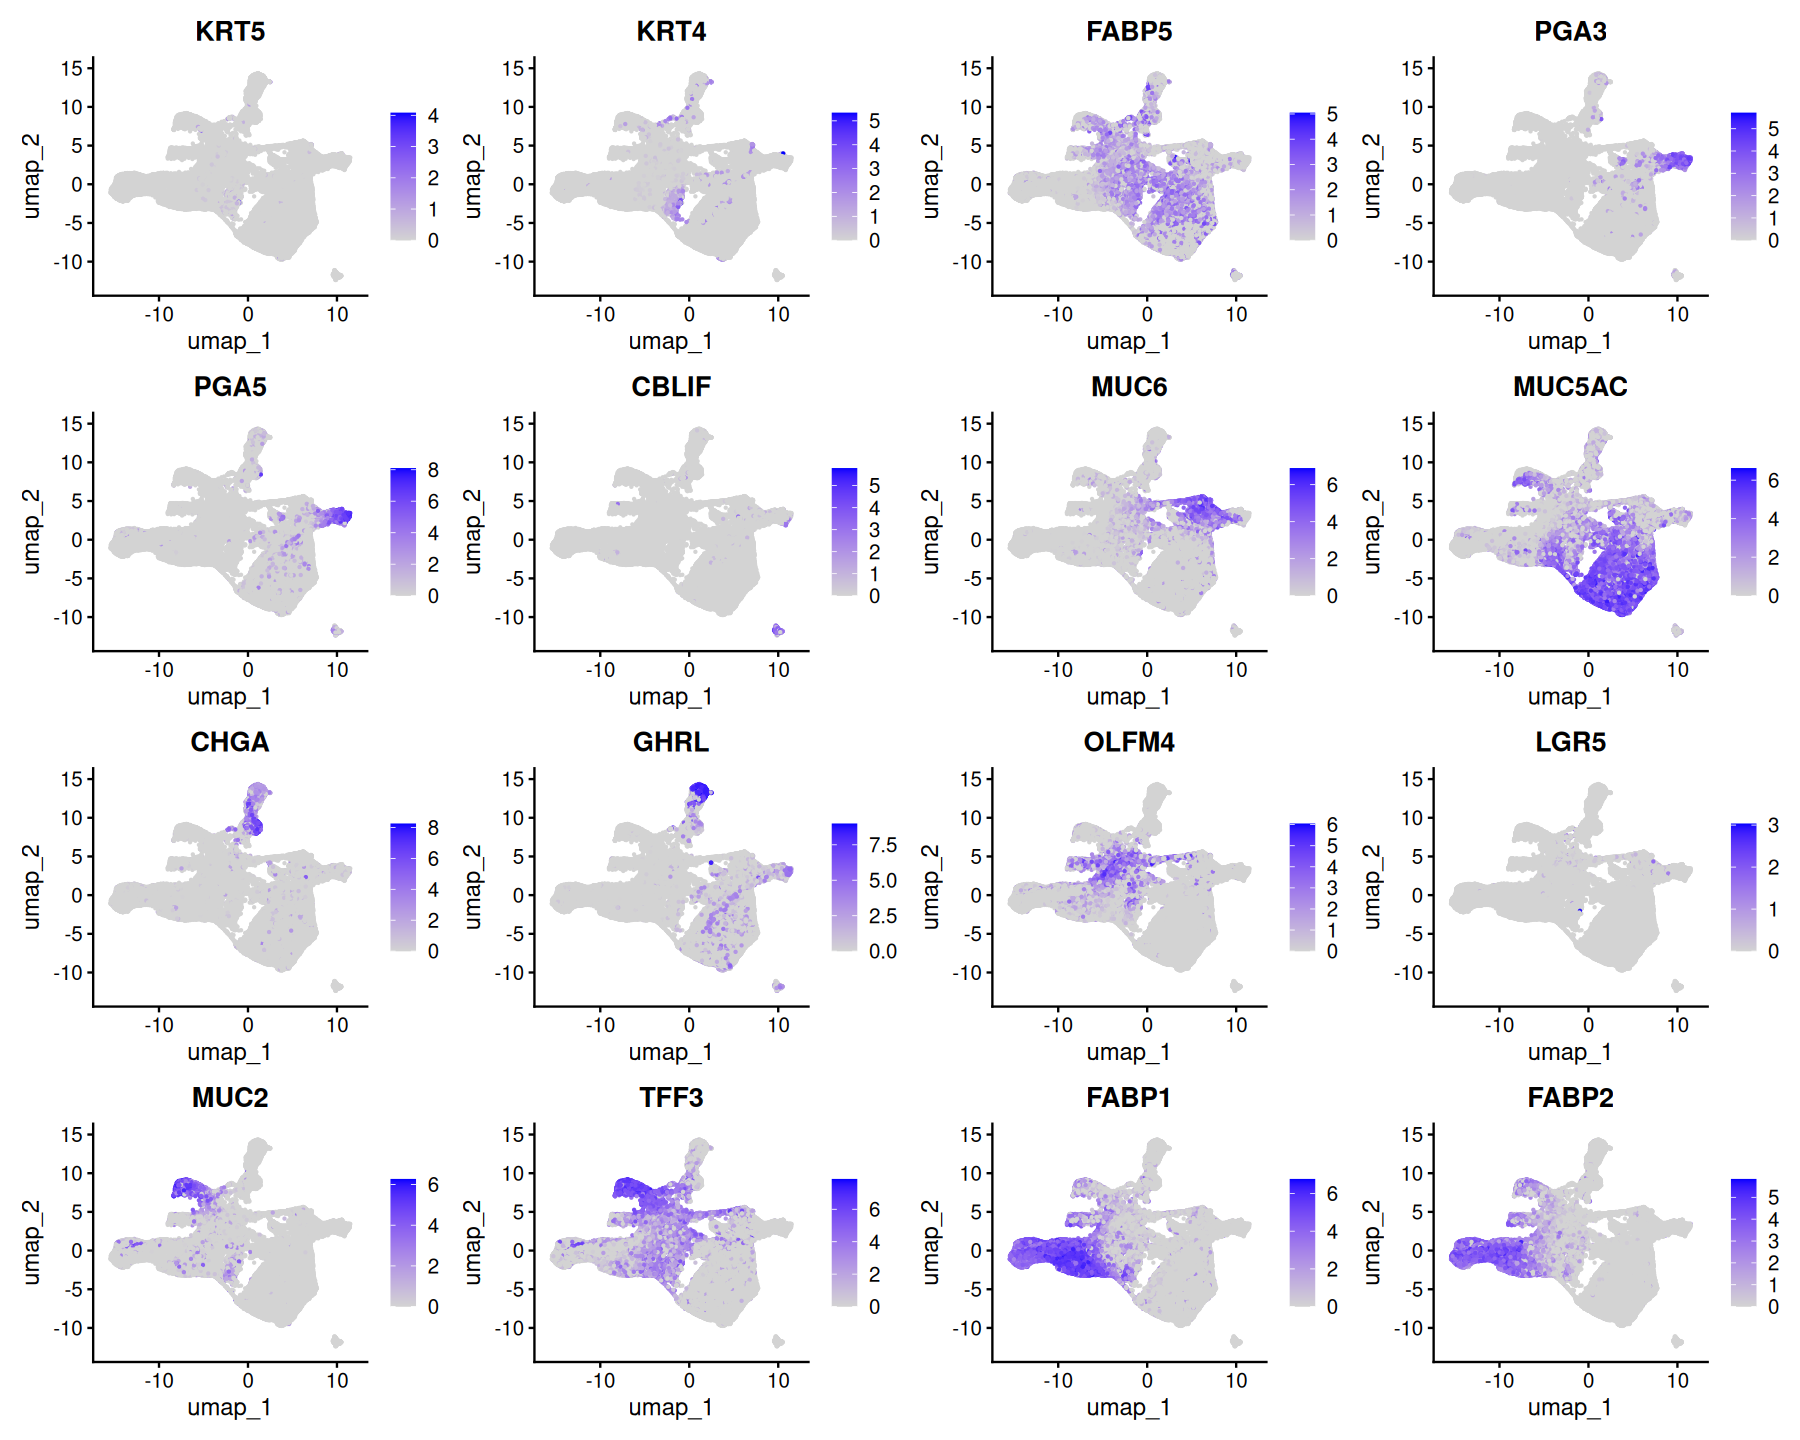

In [155]:
options(repr.plot.width =15, repr.plot.height=12)
 
FeaturePlot(AllTissue_merge,features = unique(Markers_kno))


In [156]:
png('./01_NMF_res/FeaturePlot.png',width = 15,height = 12,units = 'in',res =300)
FeaturePlot(AllTissue_merge,features = unique(Markers_kno))

dev.off()

pdf 
  2

In [86]:
Consensus_markers_list <- split(Consensus_markers$gene,Consensus_markers$cluster)

Consensus_markers_list$`0`

Consensus_markers_list$`1`

saveRDS(AllTissue_merge,'./01_NMF_res/AllTissue_merge.rds')

[1] "GKN2"    "MUC5AC"  "MSMB"    "CLDN18"  "S100P"   "KLF2"    "TACSTD2"
 [8] "TFF1"    "ANXA10"  "CTSE"    "FOXQ1"

[1] "CXCL17"  "TACSTD2" "ADH1C"   "TM4SF1"  "FOXQ1"   "ALDH3A1" "CXCL8"  
 [8] "CXCL3"   "MMP1"    "EPHA2"   "LYZ"

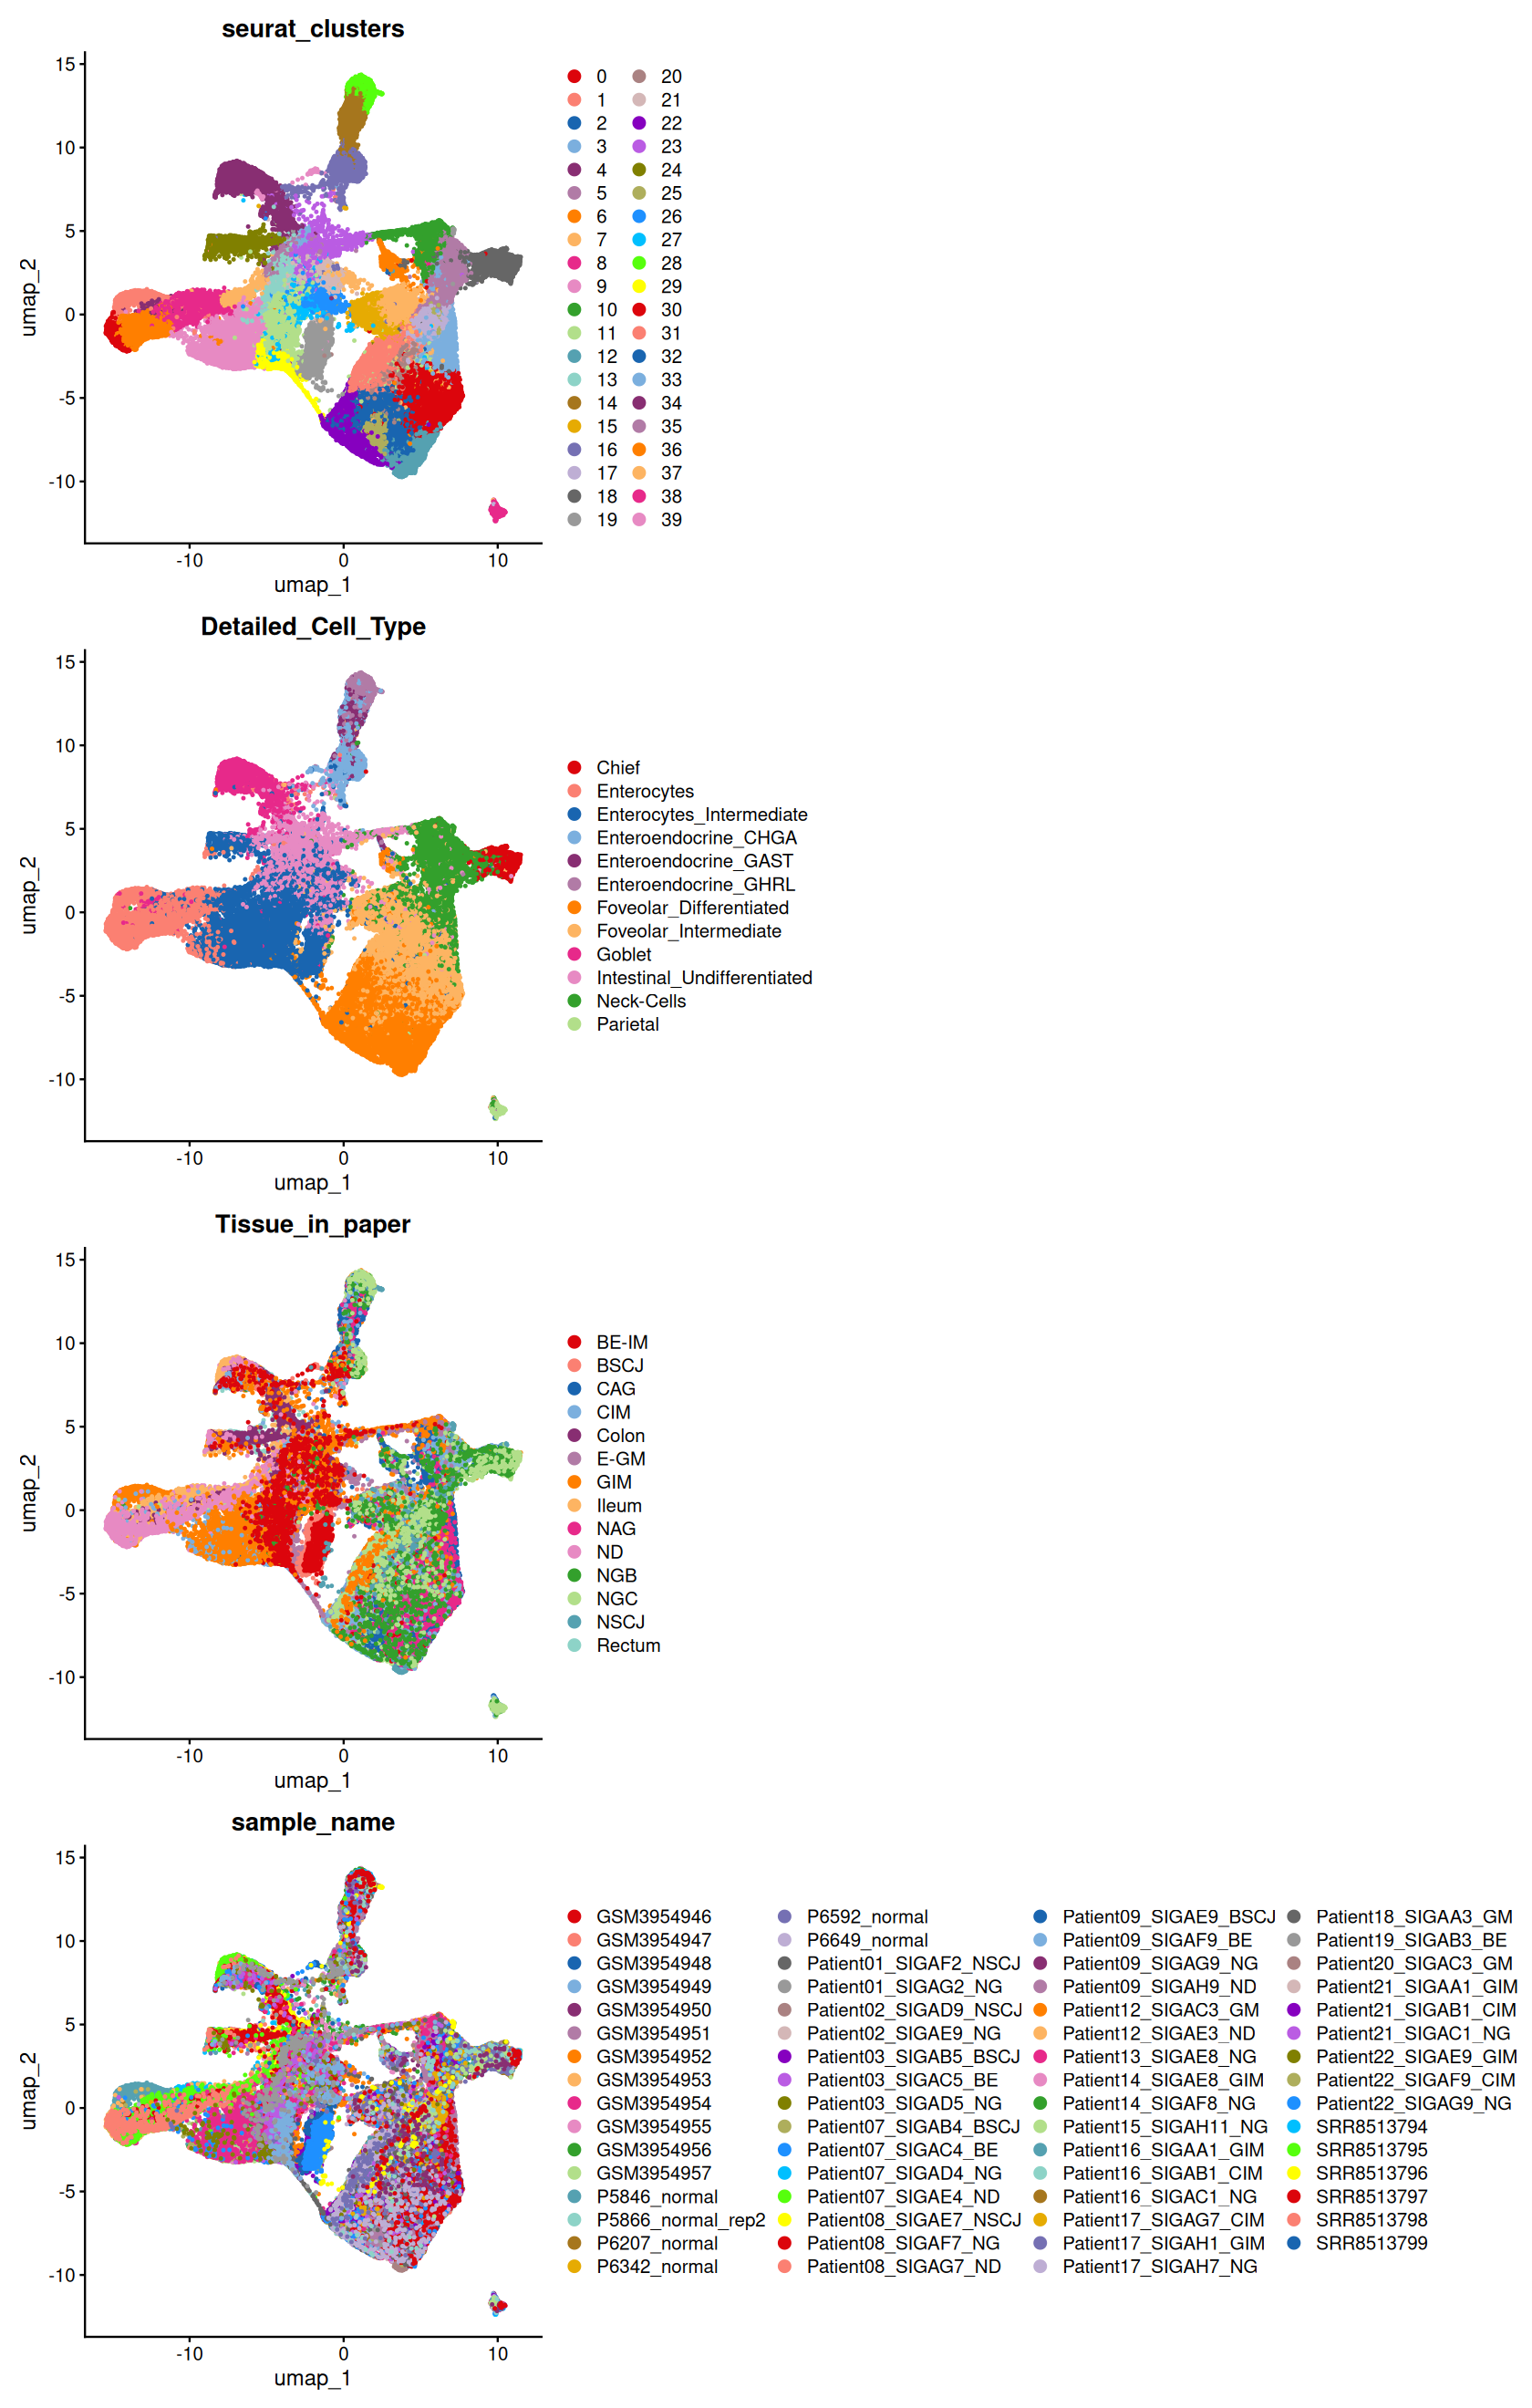

In [126]:
options(repr.plot.width =14, repr.plot.height=22)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c("seurat_clusters","Detailed_Cell_Type","Tissue_in_paper",'sample_name'),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))


pdf('./01_NMF_res/DimPlot.pdf',width = 14,height = 22)
DimPlot(AllTissue_merge,reduction = "umap",group.by = c("seurat_clusters","Detailed_Cell_Type","Tissue_in_paper",'sample_name'),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))
dev.off()

png('./01_NMF_res/DimPlot.png',units = 'in',res = 300,width = 14,height = 22)
DimPlot(AllTissue_merge,reduction = "umap",group.by = c("seurat_clusters","Detailed_Cell_Type","Tissue_in_paper",'sample_name'),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))
dev.off()

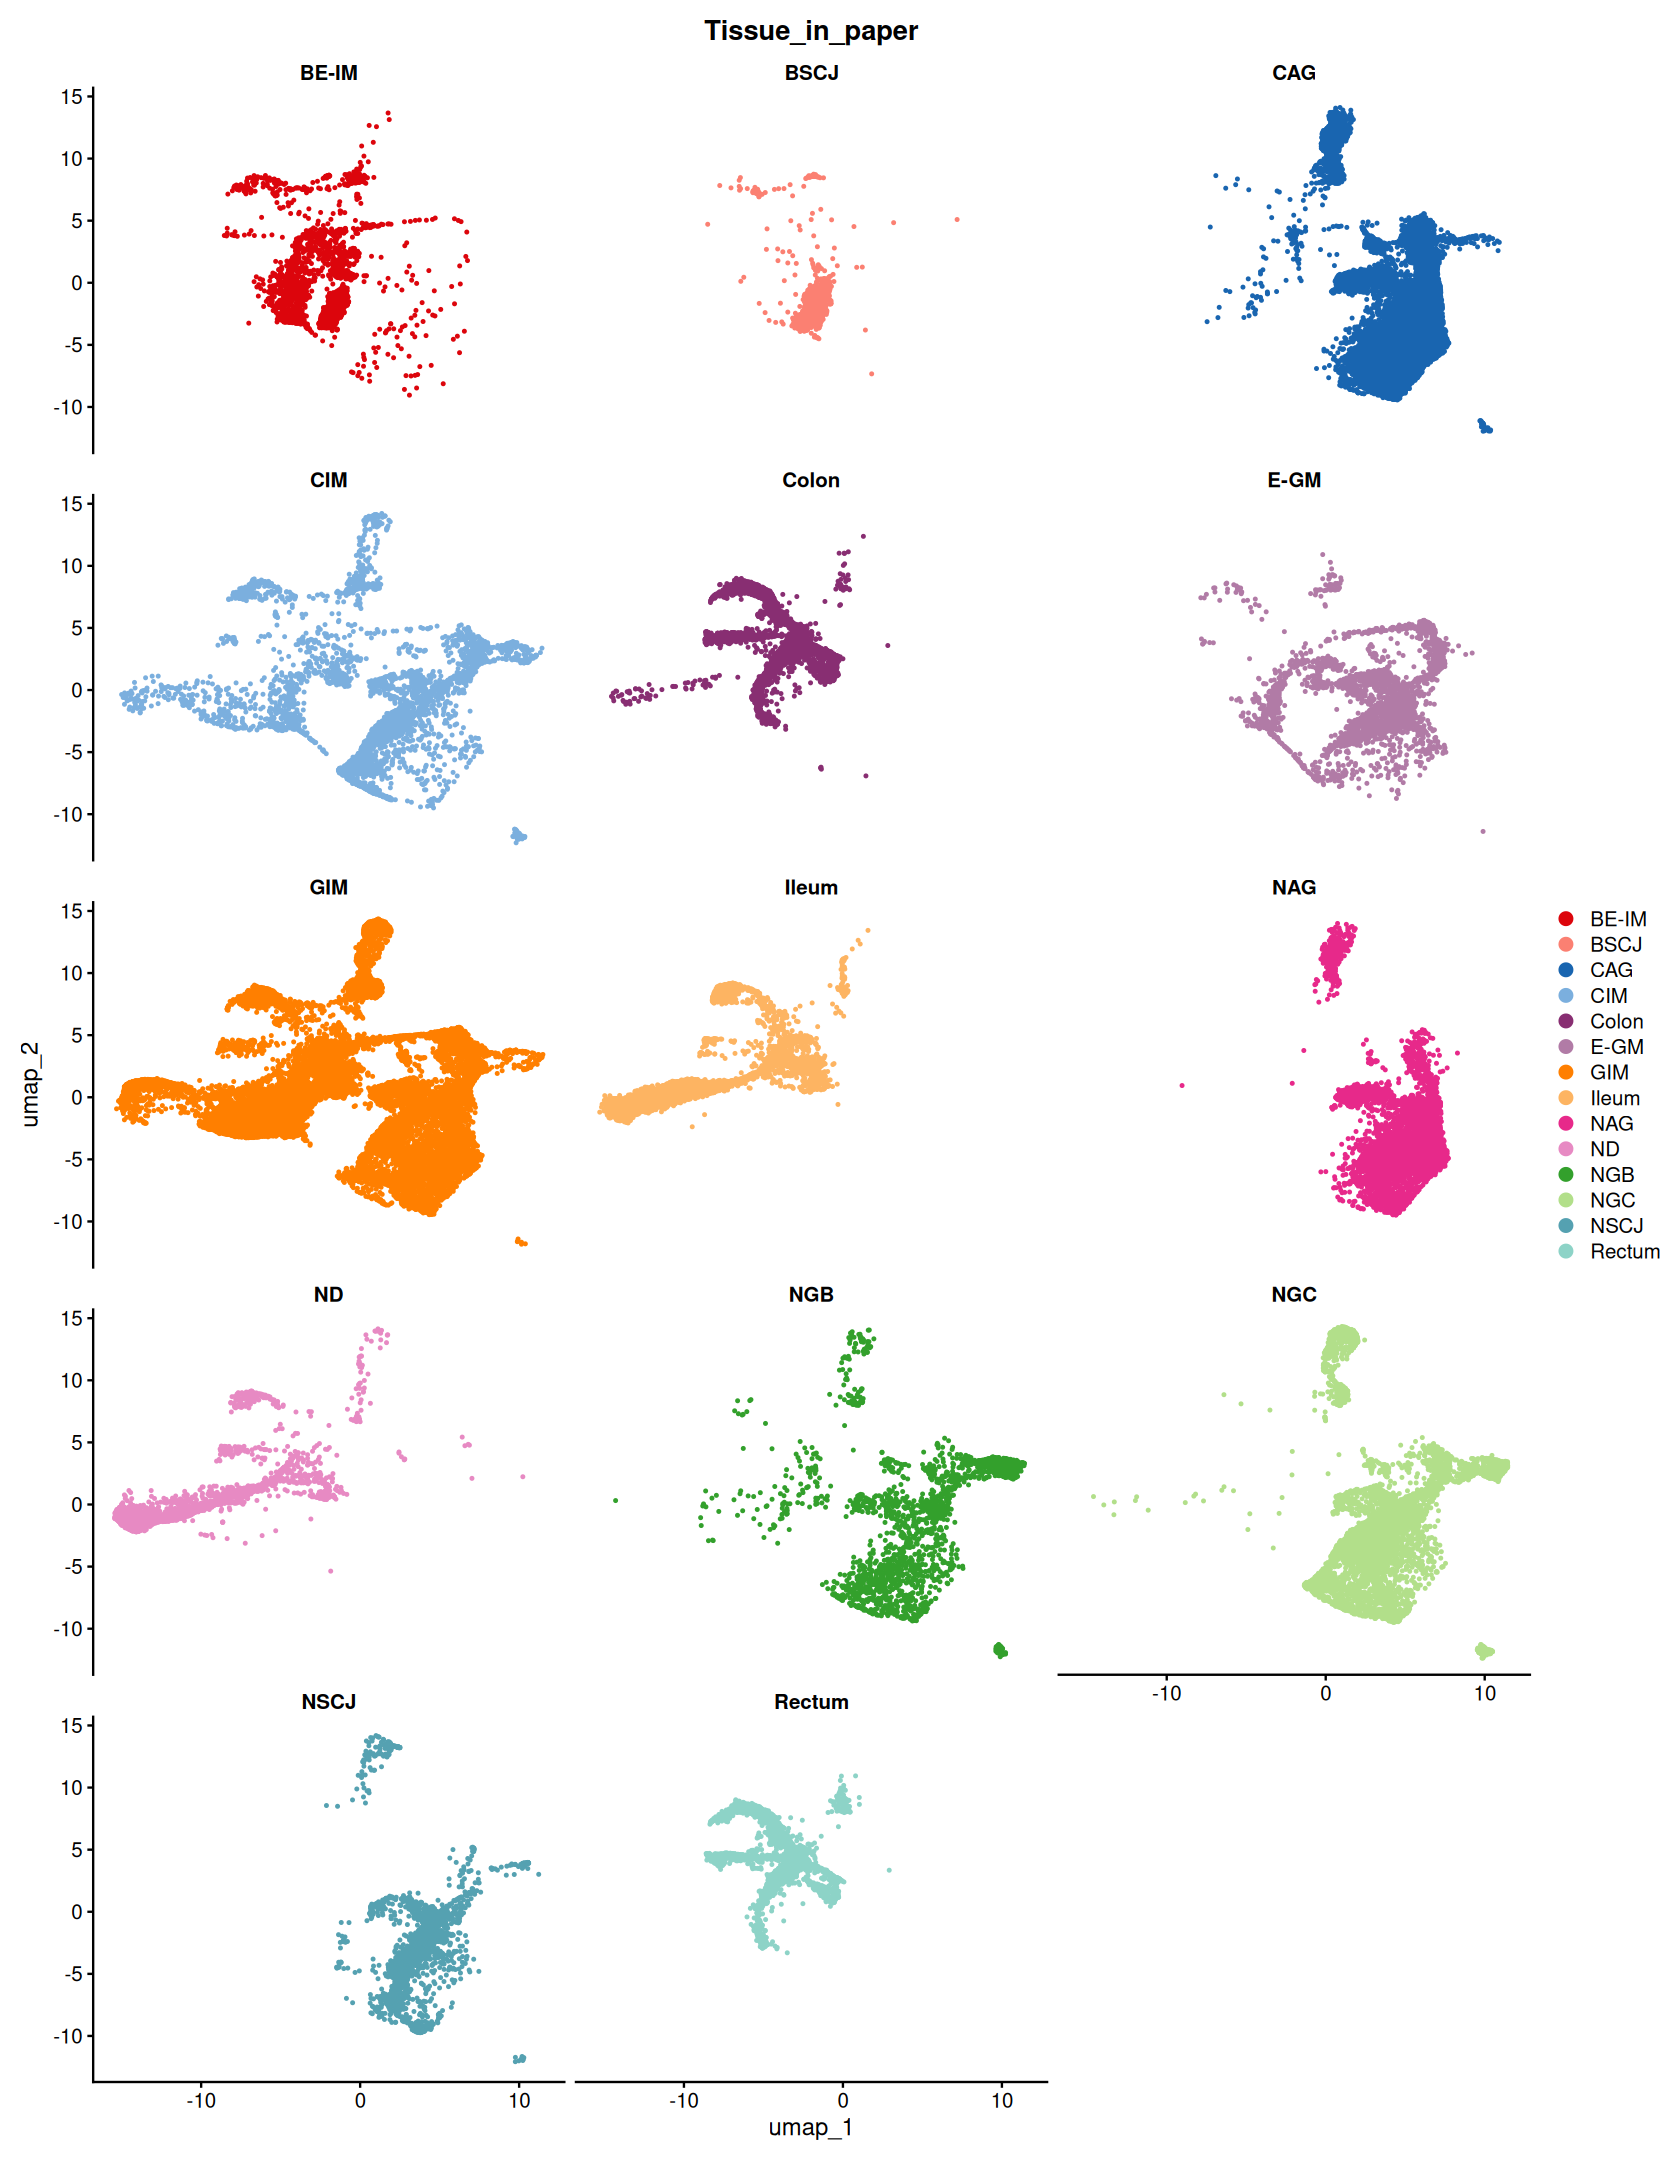

In [119]:
options(repr.plot.width =14, repr.plot.height=18)

DimPlot(AllTissue_merge,reduction = "umap",
        group.by = c("Tissue_in_paper"),split.by ='Tissue_in_paper', raster=FALSE,pt.size = 0.2,ncol = 3,cols =  rep(cluster_cols,3))


pdf('./01_NMF_res/SplitPlot.pdf',width = 14,height = 18)
DimPlot(AllTissue_merge,reduction = "umap",
        group.by = c("Tissue_in_paper"),split.by ='Tissue_in_paper', raster=FALSE,pt.size = 0.2,ncol = 3,cols =  rep(cluster_cols,3))
dev.off()

png('./01_NMF_res/SplitPlot.png',units = 'in',res = 300,width = 14,height = 18)
DimPlot(AllTissue_merge,reduction = "umap",
        group.by = c("Tissue_in_paper"),split.by ='Tissue_in_paper', raster=FALSE,pt.size = 0.2,ncol = 3,cols =  rep(cluster_cols,3))
dev.off()